<a href="https://colab.research.google.com/github/iamdreams1/Group_051_-COMP90042_Project_2026/blob/custom-reranker-%2B-custom-embedding/Group_051__COMP90042_Project_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026 COMP90042 Project
*Make sure you change the file name with your group id.*

# Readme
*If there is something to be noted for the marker, please mention here.*

*If you are planning to implement a program with Object Oriented Programming style, please put those the bottom of this ipynb file*

# 1.DataSet Processing
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [23]:
# 1.1 路径与设备配置（团队协作：Colab 走 Drive shortcut，本地走相对路径）
#
# 设计：
#   - Colab : ROOT = /content/drive/MyDrive/comp90042
#             （团队成员对该文件夹做了 shortcut，所以每个人 MyDrive 下都能看到）
#   - 本地  : ROOT = notebook 所在目录的绝对路径
#             （队友只要 clone 仓库，data/ 和 cache/ 平级即可，不用改代码）
#   - 任何人都可以用 COMP90042_ROOT 环境变量覆盖，方便挪盘
import os, sys, torch

IN_COLAB = 'google.colab' in sys.modules

# 1) 优先读环境变量（最高优先级，任何人想挪到 SSD/外接盘 export 一下就行）
ROOT = os.environ.get('COMP90042_ROOT')

# 2) Colab：挂 Drive 后用团队约定的 shortcut 路径
if ROOT is None and IN_COLAB:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    ROOT = '/content/drive/MyDrive/comp90042'

# 3) 本地：相对当前工作目录（在 notebook 同级目录启动 jupyter 即可）
if ROOT is None:
    ROOT = os.path.abspath(os.getcwd())

DATA  = os.path.join(ROOT, 'data')
CACHE = os.path.join(ROOT, 'cache')
CKPT  = os.path.join(ROOT, 'ckpt')
for p in (CACHE, CKPT):
    os.makedirs(p, exist_ok=True)

# 设备选择：cuda > mps > cpu
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print(f'IN_COLAB : {IN_COLAB}')
print(f'ROOT     : {ROOT}')
print(f'DEVICE   : {DEVICE}')
print(f'DATA     : {DATA}')
print(f'CACHE    : {CACHE}')
print(f'CKPT    : {CKPT}')


IN_COLAB : True
ROOT     : /content/drive/MyDrive/comp90042
DEVICE   : cpu
DATA     : /content/drive/MyDrive/comp90042/data
CACHE    : /content/drive/MyDrive/comp90042/cache
CKPT    : /content/drive/MyDrive/comp90042/ckpt


In [24]:
# 1.1.b 数据就位检查（团队共享 cache：避免每人重新跑重型步骤）
#
# 这一步只做“文件是否就位”的快速检查，不加载大对象。
# 真正加载/校验由后面的 cache helper 统一处理。
import os

REQUIRED = {
    'data/train-claims.json'           : True,
    'data/dev-claims.json'             : True,
    'data/test-claims-unlabelled.json' : True,
    'data/evidence.json'               : True,
}

OFFICIAL_CACHE = {
    'cache/evidence.pkl'          : 'raw evidence pickle',
    'cache/evidence_filtered.pkl' : 'filtered evidence dict + ids',
    'cache/bm25.pkl'              : 'BM25Okapi index',
    'cache/bge_evidence_emb.npy'  : 'BGE evidence embeddings',
    'cache/bge_faiss.index'       : 'FAISS dense index',
    'cache/retrieval_eval_dev.pkl': 'A1 retrieval Recall@K table',
    'cache/hybrid_dev.pkl'        : 'hybrid dev candidates',
    'cache/hybrid_train.pkl'      : 'hybrid train candidates',
    'cache/hybrid_test.pkl'       : 'hybrid test candidates',
    'cache/bm25_dev.pkl'           : 'bm25 dev candidates (baseline)',
    'cache/bm25_train.pkl'         : 'bm25 train candidates (baseline)',
    'cache/bm25_test.pkl'          : 'bm25 test candidates (baseline)',
}

print(f'检查 ROOT = {ROOT}')
print('-' * 70)
missing_required = []
for rel, required in REQUIRED.items():
    p = os.path.join(ROOT, rel)
    if os.path.exists(p):
        print(f'  ok {rel:<42s} {os.path.getsize(p)/1e6:>8.1f} MB')
    else:
        print(f'  MISSING {rel}')
        if required:
            missing_required.append(rel)

if missing_required:
    raise FileNotFoundError(
        f'缺少必需文件: {missing_required}\n'
        f'请确认 Drive shortcut 已生效，或在本地把 data/ 放到 {ROOT} 下。'
    )
print('-' * 70)
print('必需数据已就位')

print('\n官方 cache 快速检查（存在不代表有效，后面会逐项校验）')
print('-' * 70)
missing_cache = []
for rel, desc in OFFICIAL_CACHE.items():
    p = os.path.join(ROOT, rel)
    if os.path.exists(p):
        print(f'  ok {rel:<34s} {os.path.getsize(p)/1e6:>8.1f} MB  ({desc})')
    else:
        print(f'  missing {rel:<34s} ({desc})')
        missing_cache.append(rel)

HYBRID_CACHE_RELS = ['cache/hybrid_dev.pkl', 'cache/hybrid_train.pkl', 'cache/hybrid_test.pkl']
BM25_CACHE_RELS   = ['cache/bm25_dev.pkl',   'cache/bm25_train.pkl',   'cache/bm25_test.pkl']
ALL_HYBRID_FILES_PRESENT = all(os.path.exists(os.path.join(ROOT, rel)) for rel in HYBRID_CACHE_RELS)
ALL_BM25_FILES_PRESENT   = all(os.path.exists(os.path.join(ROOT, rel)) for rel in BM25_CACHE_RELS)
print('\nFast-path summary:')
print(f'  hybrid candidate files present : {ALL_HYBRID_FILES_PRESENT}')
print(f'  bm25 candidate files present   : {ALL_BM25_FILES_PRESENT}')


检查 ROOT = /content/drive/MyDrive/comp90042
----------------------------------------------------------------------
  ok data/train-claims.json                          0.3 MB
  ok data/dev-claims.json                            0.0 MB
  ok data/test-claims-unlabelled.json                0.0 MB
  ok data/evidence.json                            174.2 MB
----------------------------------------------------------------------
必需数据已就位

官方 cache 快速检查（存在不代表有效，后面会逐项校验）
----------------------------------------------------------------------
  ok cache/evidence.pkl                    170.5 MB  (raw evidence pickle)
  ok cache/evidence_filtered.pkl           188.6 MB  (filtered evidence dict + ids)
  ok cache/bm25.pkl                        190.0 MB  (BM25Okapi index)
  ok cache/bge_evidence_emb.npy           3713.5 MB  (BGE evidence embeddings)
  ok cache/bge_faiss.index                3713.5 MB  (FAISS dense index)
  ok cache/retrieval_eval_dev.pkl            0.7 MB  (A1 retrieval Recall@K table)

In [25]:
# 1.2 NLTK 资源（如果是 Colab 第一次跑，取消下面 pip 注释）
!pip install -q rank_bm25 sentencepiece protobuf tiktoken sentence-transformers==2.7.0 transformers==4.40.0 nltk pandas matplotlib scikit-learn peft==0.9.0 accelerate
import importlib.util
import nltk

for module_name in ['sentencepiece', 'transformers', 'tokenizers']:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f'{module_name} 未安装成功；请重新运行本 cell，必要时 Runtime > Restart runtime 后再 Run all')

def ensure_nltk_resource(pkg, path, required=True):
    try:
        nltk.data.find(path)
    except (LookupError, OSError):
        ok = nltk.download(pkg, quiet=True)
        if required and not ok:
            raise RuntimeError(f'下载 NLTK 资源 {pkg} 失败')

ensure_nltk_resource('punkt',      'tokenizers/punkt')
ensure_nltk_resource('punkt_tab',  'tokenizers/punkt_tab', required=False)  # 新版 nltk 才有
ensure_nltk_resource('stopwords',  'corpora/stopwords')
print('✓ tokenizer 依赖就绪（sentencepiece / transformers / tokenizers）')
print('✓ NLTK 资源就绪')

✓ tokenizer 依赖就绪（sentencepiece / transformers / tokenizers）
✓ NLTK 资源就绪


In [26]:
# 1.2.b Cache helpers（必须先于所有重型 cache 使用）
import os, pickle, gc, time

FORCE_REBUILD = {
    'filtered': False,
    'bm25': False,
    'bge': False,
    'eval': False,
    'hybrid': False,
}

CACHE_META = {
    'filtered': {
        'version': 1,
        'max_words': 256,
        'min_words_threshold': 3,
    },
    'bm25': {
        'version': 1,
        'tokenizer': 'nltk_word_tokenize_lower_stopwords_punct_isalnum_v1',
        'max_words': 256,
        'min_words_threshold': 3,
    },
    'bge': {
        'version': 1,
        'model': 'BAAI/bge-base-en-v1.5',
        'max_seq_len': 384,
        'embedding_dim': 768,
    },
    'hybrid': {
        'version': 1,
        'k_each': 200,
        'mode': 'bm25_first_union_v1',
    },
}


def save_pickle_atomic(data, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, path)


def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


def release_large_objects(*names):
    released = []
    for name in names:
        if name in globals():
            del globals()[name]
            released.append(name)
    if released:
        gc.collect()
        if 'torch' in globals() and getattr(torch, 'cuda', None) and torch.cuda.is_available():
            torch.cuda.empty_cache()
        print('released:', ', '.join(released))


def validate_candidate_cache(data, claims, name='cache', max_len=None, known_evidence=None):
    if not isinstance(data, dict):
        return False, f'{name} is not a dict'
    expected = set(claims.keys())
    actual = set(data.keys())
    missing = expected - actual
    extra = actual - expected
    if missing or extra:
        return False, f'{name} claim ids mismatch: missing={len(missing)} extra={len(extra)}'
    for cid, vals in data.items():
        if not isinstance(vals, list):
            return False, f'{name}[{cid}] is not a list'
        if max_len is not None and len(vals) > max_len:
            return False, f'{name}[{cid}] has {len(vals)} candidates > {max_len}'
        if len(vals) != len(set(vals)):
            return False, f'{name}[{cid}] contains duplicate evidence ids'
        if known_evidence is not None:
            bad = [eid for eid in vals if eid not in known_evidence]
            if bad:
                return False, f'{name}[{cid}] contains unknown evidence id {bad[0]}'
    return True, 'ok'


def load_candidate_cache(path, claims, name='cache', max_len=None, known_evidence=None, force=False):
    if force or not os.path.exists(path):
        reason = 'forced rebuild' if force else 'missing file'
        print(f'  {name}: {reason}')
        return None
    try:
        t0 = time.time()
        data = load_pickle(path)
        ok, msg = validate_candidate_cache(data, claims, name=name, max_len=max_len, known_evidence=known_evidence)
        if ok:
            avg = sum(len(v) for v in data.values()) / max(1, len(data))
            print(f'  loaded {path} ({len(data)} claims, avg {avg:.0f}, {time.time()-t0:.1f}s)')
            return data
        print(f'  invalid {name}: {msg}; rebuilding')
    except Exception as e:
        print(f'  failed to load {name} ({type(e).__name__}: {e}); rebuilding')
    return None

print('Cache-first helpers ready')
print('FORCE_REBUILD =', FORCE_REBUILD)


Cache-first helpers ready
FORCE_REBUILD = {'filtered': False, 'bm25': False, 'bge': False, 'eval': False, 'hybrid': False}


In [27]:
# 1.3 读取数据
import os, json, pickle, time

os.makedirs(CACHE, exist_ok=True)

def load_json(name):
    with open(f'{DATA}/{name}.json') as f:
        return json.load(f)

t0 = time.time()
train    = load_json('train-claims')
dev      = load_json('dev-claims')
test     = load_json('test-claims-unlabelled')
baseline = load_json('dev-claims-baseline')
print(f'Claims loaded in {time.time()-t0:.1f}s | '
      f'train={len(train)} dev={len(dev)} test={len(test)} baseline={len(baseline)}')

# evidence.json 174MB，首次加载后写入 pickle；后续只读 pickle。
evi_pkl = f'{CACHE}/evidence.pkl'
if os.path.exists(evi_pkl):
    print('从 pickle 缓存加载 evidence ...')
    t0 = time.time()
    evidence = load_pickle(evi_pkl)
    print(f'  loaded in {time.time()-t0:.1f}s | {len(evidence):,} passages')
else:
    print('首次加载 evidence.json (174MB) ...')
    t0 = time.time()
    evidence = load_json('evidence')
    print(f'  loaded in {time.time()-t0:.1f}s | {len(evidence):,} passages')
    save_pickle_atomic(evidence, evi_pkl)
    print(f'  cached -> {evi_pkl}')

evi_ids = list(evidence.keys())
print(f'\n首 3 个 evi_id: {evi_ids[:3]}')
print(f'Evidence corpus 大小: {len(evi_ids):,} passages')


Claims loaded in 0.0s | train=1228 dev=154 test=153 baseline=154
从 pickle 缓存加载 evidence ...
  loaded in 9.5s | 1,208,827 passages

首 3 个 evi_id: ['evidence-0', 'evidence-1', 'evidence-2']
Evidence corpus 大小: 1,208,827 passages


In [28]:
# 1.4 抽样查看一条 train 数据，确认 schema
import random
random.seed(0)

cid = random.choice(list(train.keys()))
sample = train[cid]
print(f'claim_id     : {cid}')
print(f'claim_text   : {sample["claim_text"]}')
print(f'claim_label  : {sample["claim_label"]}')
print(f'gold evi ids : {sample["evidences"]}')
print()
for eid in sample['evidences'][:2]:
    print(f'  [{eid}] {evidence[eid][:200]} ...')

# Test 集对比（无 label / 无 gold evidences）
print()
print('Test 字段（应无 claim_label / evidences）:')
print(f'  {list(next(iter(test.values())).keys())}')

claim_id     : claim-1553
claim_text   : 2009-2010 winter saw record cold spells.
claim_label  : SUPPORTS
gold evi ids : ['evidence-501934']

  [evidence-501934] In Europe, the winters of early 1947, February 1956, 1962–1963, 1981–1982 and 2009–2010 were abnormally cold. ...

Test 字段（应无 claim_label / evidences）:
  ['claim_text']


## 1.5 EDA：长度分布、标签分布、evidence 数

四张图一次出，写报告时直接引用：

| 子图 | 用途 |
|---|---|
| Claim 长度 | 决定 tokenizer max_length（claim 端） |
| 4 类标签分布 | 论证 class weight 必要性，DISPUTED 极少 |
| 每条 claim 的 gold evidence 数 | 决定最终输出 evidence 的 Top-K 大小 |
| Evidence 长度（log scale） | 决定 evidence 端截断策略 |

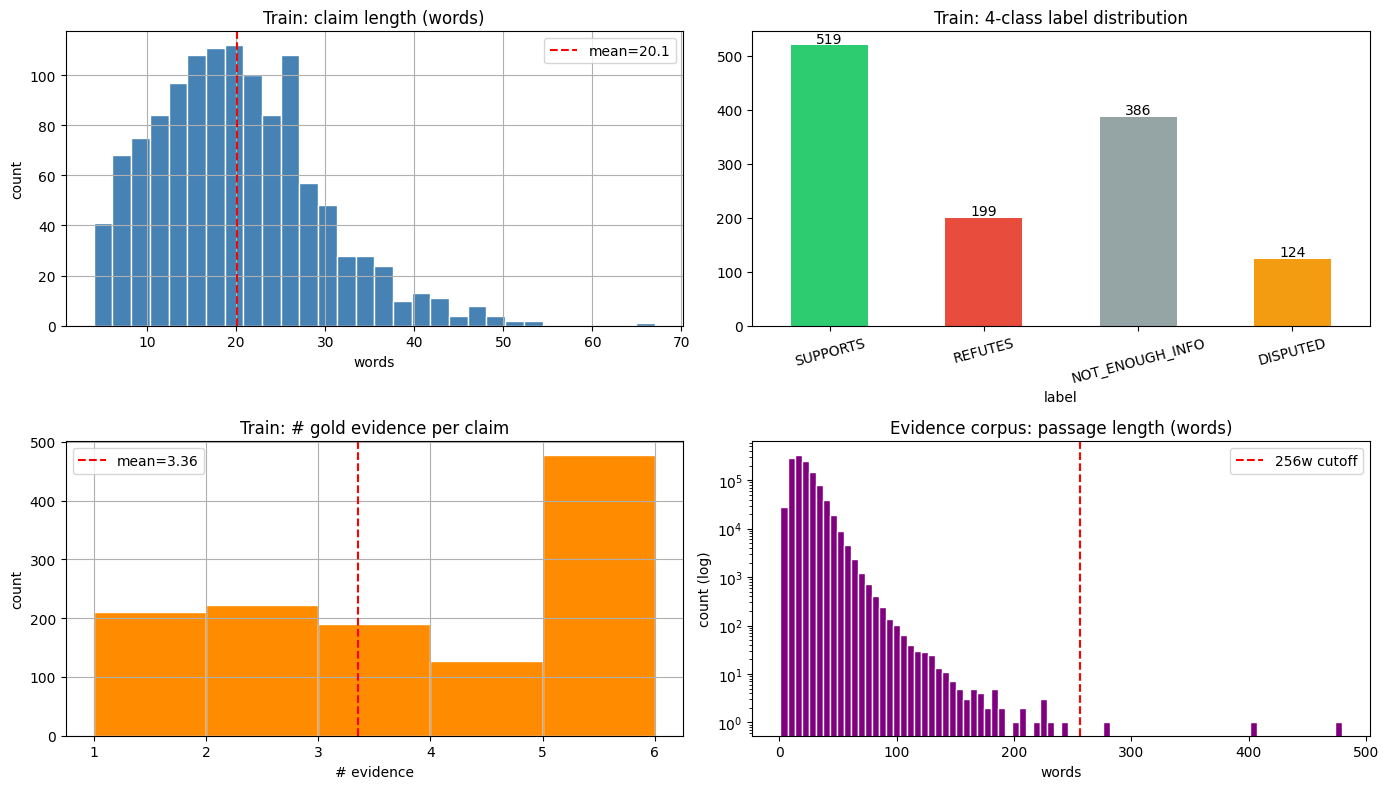

Claim 长度: mean=20.1, p95=37
Gold evidence 数: mean=3.36, p95=5
Evidence 长度: p50=18, p95=39, p99=53, >256w 占比 0.00%


In [29]:
# 1.5 EDA: 4 张子图
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']

# Train claim 维度
df = pd.DataFrame([{
    'claim_len' : len(v['claim_text'].split()),
    'label'     : v['claim_label'],
    'n_evi'     : len(v['evidences']),
} for v in train.values()])

# Evidence 长度（先算一遍，下面要用）
evi_lens = np.array([len(evidence[eid].split()) for eid in evi_ids])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (1) claim 长度
df['claim_len'].hist(ax=axes[0,0], bins=30, color='steelblue', edgecolor='white')
axes[0,0].set_title('Train: claim length (words)')
axes[0,0].set_xlabel('words'); axes[0,0].set_ylabel('count')
axes[0,0].axvline(df['claim_len'].mean(), color='red', linestyle='--',
                  label=f"mean={df['claim_len'].mean():.1f}")
axes[0,0].legend()

# (2) 4 类标签分布
label_counts = df['label'].value_counts().reindex(LABELS)
label_counts.plot(kind='bar', ax=axes[0,1],
                  color=['#2ecc71','#e74c3c','#95a5a6','#f39c12'])
axes[0,1].set_title('Train: 4-class label distribution')
axes[0,1].set_xticklabels(LABELS, rotation=15)
for i, v in enumerate(label_counts):
    axes[0,1].text(i, v + 5, str(v), ha='center')

# (3) 每条 claim 的 gold evidence 数
n_evi_max = df['n_evi'].max()
df['n_evi'].hist(ax=axes[1,0], bins=range(1, n_evi_max + 2),
                 color='darkorange', edgecolor='white')
axes[1,0].set_title('Train: # gold evidence per claim')
axes[1,0].set_xlabel('# evidence'); axes[1,0].set_ylabel('count')
axes[1,0].axvline(df['n_evi'].mean(), color='red', linestyle='--',
                  label=f"mean={df['n_evi'].mean():.2f}")
axes[1,0].legend()

# (4) Evidence 长度（log y 因为长尾很重）
axes[1,1].hist(evi_lens, bins=80, color='purple', edgecolor='white')
axes[1,1].set_yscale('log')
axes[1,1].set_title('Evidence corpus: passage length (words)')
axes[1,1].set_xlabel('words'); axes[1,1].set_ylabel('count (log)')
axes[1,1].axvline(256, color='red', linestyle='--', label='256w cutoff')
axes[1,1].legend()

plt.tight_layout()
plt.savefig(f'{CACHE}/eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()

# 关键数字打印（写报告用）
print(f'Claim 长度: mean={df["claim_len"].mean():.1f}, p95={df["claim_len"].quantile(0.95):.0f}')
print(f'Gold evidence 数: mean={df["n_evi"].mean():.2f}, p95={df["n_evi"].quantile(0.95):.0f}')
print(f'Evidence 长度: p50={int(np.percentile(evi_lens,50))}, '
      f'p95={int(np.percentile(evi_lens,95))}, p99={int(np.percentile(evi_lens,99))}, '
      f'>256w 占比 {(evi_lens > 256).mean()*100:.2f}%')

In [30]:
# 1.6 evidence filtering cache（默认加载 cache/evidence_filtered.pkl）
import time, gc
from collections import Counter

MAX_WORDS = CACHE_META['filtered']['max_words']
MIN_WORDS_THRESHOLD = CACHE_META['filtered']['min_words_threshold']
FILTERED_CACHE = f'{CACHE}/evidence_filtered.pkl'


def validate_filtered_cache(obj):
    if not isinstance(obj, dict):
        return False, 'cache is not a dict'
    required = {'meta', 'evidence_filtered', 'evi_ids_filtered', 'evidence_tags', 'original_count'}
    if not required.issubset(obj):
        return False, f'missing keys: {sorted(required - set(obj))}'
    meta = obj.get('meta', {})
    if meta.get('max_words') != MAX_WORDS or meta.get('min_words_threshold') != MIN_WORDS_THRESHOLD:
        return False, 'filter config mismatch'
    ef = obj['evidence_filtered']
    ids = obj['evi_ids_filtered']
    tags = obj['evidence_tags']
    if not isinstance(ef, dict) or not isinstance(ids, list) or not isinstance(tags, dict):
        return False, 'invalid object types'
    if len(ef) != len(ids) or ids != list(ef.keys()):
        return False, 'filtered evidence id order mismatch'
    return True, 'ok'

loaded_filtered = False
if os.path.exists(FILTERED_CACHE) and not FORCE_REBUILD['filtered']:
    try:
        t0 = time.time()
        obj = load_pickle(FILTERED_CACHE)
        ok, msg = validate_filtered_cache(obj)
        if ok:
            evidence_filtered = obj['evidence_filtered']
            evi_ids_filtered = obj['evi_ids_filtered']
            evidence_tags = obj['evidence_tags']
            original_evidence_count = obj['original_count']
            loaded_filtered = True
            print(f'Loaded filtered evidence cache in {time.time()-t0:.1f}s -> {FILTERED_CACHE}')
        else:
            print(f'Invalid filtered cache: {msg}; rebuilding')
    except Exception as e:
        print(f'Failed to load filtered cache ({type(e).__name__}: {e}); rebuilding')

if not loaded_filtered:
    if 'evidence' not in globals():
        raise RuntimeError('Raw evidence is missing. Run the data loading cell first.')
    t0 = time.time()
    evidence_filtered = {}
    evidence_tags = {}
    for eid, text in evidence.items():
        word_count = len(text.split())
        if word_count > MAX_WORDS:
            continue
        evidence_filtered[eid] = text
        evidence_tags[eid] = 'short' if word_count < MIN_WORDS_THRESHOLD else 'standard'
    evi_ids_filtered = list(evidence_filtered.keys())
    original_evidence_count = len(evidence)
    obj = {
        'meta': dict(CACHE_META['filtered']),
        'evidence_filtered': evidence_filtered,
        'evi_ids_filtered': evi_ids_filtered,
        'evidence_tags': evidence_tags,
        'original_count': original_evidence_count,
    }
    save_pickle_atomic(obj, FILTERED_CACHE)
    print(f'Built filtered evidence in {time.time()-t0:.1f}s -> {FILTERED_CACHE}')

print(f'Original passages: {original_evidence_count:,}')
print(f'Remaining passages: {len(evidence_filtered):,}')
print(f'Removed (Too Long): {original_evidence_count - len(evidence_filtered):,}')
print(f"Tagged as 'Short':   {list(evidence_tags.values()).count('short'):,}")

# 后续只需要 filtered corpus；释放 raw evidence 降低 Colab RAM 峰值。
release_large_objects('evidence', 'evi_ids')


Loaded filtered evidence cache in 10.7s -> /content/drive/MyDrive/comp90042/cache/evidence_filtered.pkl
Original passages: 1,208,827
Remaining passages: 1,208,824
Removed (Too Long): 3
Tagged as 'Short':   1,789
released: evidence, evi_ids


In [31]:
train_pairs = []

# Process all claims in train-claims.json
for cid, data in train.items():
    label = data['claim_label']
    claim_text = data['claim_text']
    gold_ids = data.get('evidences', [])

    for eid in gold_ids:
        # Check if the evidence exists in our filtered dictionary
        if eid in evidence_filtered:
            train_pairs.append({
                "claim": claim_text,
                "evidence": evidence_filtered[eid],
                "label": label,
                "claim_id": cid,
                "evidence_id": eid
            })

print(f"Total training pairs generated: {len(train_pairs):,}")

Total training pairs generated: 4,121


# 2.Model Implementation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

In [32]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string

nltk.download('punkt')
nltk.download('stopwords')

# Pre-loading stopwords and punctuation for speed
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [33]:
def nltk_tokenize(text):
    # Standard NLTK tokenization
    tokens = word_tokenize(text.lower())

    # Filter out stopwords and punctuation to keep the index clean
    # and improve retrieval relevance for scientific terms
    filtered = [
        t for t in tokens
        if t not in stop_words and t not in punctuation and t.isalnum()
    ]
    return filtered

In [34]:
# 2.1 BM25 cache（默认加载 cache/bm25.pkl；缺失或无效才重建）
import time, gc
from rank_bm25 import BM25Okapi
from tqdm.auto import tqdm

BM25_CACHE = f'{CACHE}/bm25.pkl'
BM25_META = dict(CACHE_META['bm25'])


def unpack_bm25_cache(obj):
    # New format: {'meta': ..., 'bm25': ..., 'evi_ids_filtered': ...}
    if isinstance(obj, dict) and {'bm25', 'evi_ids_filtered'}.issubset(obj):
        return obj.get('bm25'), obj.get('evi_ids_filtered'), obj.get('meta'), False
    # Backward-compatible legacy format already used by this project: (bm25, ids)
    if isinstance(obj, tuple) and len(obj) == 2:
        return obj[0], obj[1], None, True
    return None, None, None, False


def validate_bm25_cache(obj):
    cached_bm25, cached_ids, meta, legacy = unpack_bm25_cache(obj)
    if cached_bm25 is None or cached_ids is None:
        return False, 'unrecognized BM25 cache format', None
    if list(cached_ids) != list(evi_ids_filtered):
        return False, 'evidence id order mismatch', None
    if getattr(cached_bm25, 'corpus_size', None) != len(evi_ids_filtered):
        return False, 'BM25 corpus size mismatch', None
    if meta is not None and meta != BM25_META:
        return False, 'BM25 tokenizer/filter metadata mismatch', None
    if legacy:
        print('  note: legacy BM25 cache has no metadata; accepted after id-order and corpus-size checks')
    return True, 'ok', cached_bm25


def build_bm25_cache():
    print('Tokenizing filtered evidence with NLTK... (only runs on cache miss/force rebuild)')
    t0 = time.time()
    corpus_tokens = []
    for eid in tqdm(evi_ids_filtered, desc='BM25 tokenize'):
        corpus_tokens.append(nltk_tokenize(evidence_filtered[eid]))
    print(f'Tokenization finished in {time.time()-t0:.1f}s')

    print('Building BM25Okapi index...')
    t0 = time.time()
    built_bm25 = BM25Okapi(corpus_tokens)
    del corpus_tokens
    gc.collect()
    print(f'BM25 built in {time.time()-t0:.1f}s')

    save_pickle_atomic({
        'meta': BM25_META,
        'bm25': built_bm25,
        'evi_ids_filtered': list(evi_ids_filtered),
    }, BM25_CACHE)
    print(f'BM25 cache saved -> {BM25_CACHE}')
    return built_bm25

bm25 = None
if os.path.exists(BM25_CACHE) and not FORCE_REBUILD['bm25']:
    try:
        t0 = time.time()
        obj = load_pickle(BM25_CACHE)
        ok, msg, loaded_bm25 = validate_bm25_cache(obj)
        if ok:
            bm25 = loaded_bm25
            print(f'BM25 loaded from cache in {time.time()-t0:.1f}s -> {BM25_CACHE}')
        else:
            print(f'Invalid BM25 cache: {msg}; rebuilding')
    except Exception as e:
        print(f'Failed to load BM25 cache ({type(e).__name__}: {e}); rebuilding')

if bm25 is None:
    bm25 = build_bm25_cache()


BM25 loaded from cache in 17.3s -> /content/drive/MyDrive/comp90042/cache/bm25.pkl


In [35]:
def get_top_200(claim_text, n=200):
    required = ['bm25', 'evi_ids_filtered', 'evidence_filtered', 'nltk_tokenize']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError(
            'Missing prerequisites: ' + ', '.join(missing) +
            '. Run data filtering, tokenizer setup, and BM25 cache cells first.'
        )

    query_tokens = nltk_tokenize(claim_text)
    scores = bm25.get_scores(query_tokens)

    import numpy as np
    n = max(1, min(n, len(scores)))
    top_indices = np.argsort(scores)[-n:][::-1]

    results = []
    for idx in top_indices:
        eid = evi_ids_filtered[idx]
        results.append({
            'id': eid,
            'text': evidence_filtered[eid],
            'score': float(scores[idx]),
        })
    return results

# Lightweight smoke test: BM25 only, no dense/BGE objects involved.
if 'train' not in globals() or len(train) == 0:
    raise RuntimeError('`train` is missing or empty. Please run data loading cell first.')

example_cid = 'claim-1937' if 'claim-1937' in train else next(iter(train))
example_claim = train[example_cid]['claim_text']
top_evidences = get_top_200(example_claim)
print(f'Example claim ID: {example_cid}')
print(f"Top result ID: {top_evidences[0]['id']}")


Example claim ID: claim-1937
Top result ID: evidence-66273


In [36]:
# 2.2 Dense retrieval dependencies（仅在需要 BGE/FAISS 时安装 faiss）
import importlib.util, subprocess, sys, os

EVAL_CACHE_PATH = f'{CACHE}/retrieval_eval_dev.pkl'
HYBRID_CACHE_PATHS = {
    'dev': f'{CACHE}/hybrid_dev.pkl',
    'train': f'{CACHE}/hybrid_train.pkl',
    'test': f'{CACHE}/hybrid_test.pkl',
}

NEED_DENSE_DEPS = (
    FORCE_REBUILD['bge'] or
    FORCE_REBUILD['hybrid'] or
    FORCE_REBUILD['eval'] or
    (not os.path.exists(EVAL_CACHE_PATH)) or
    any(not os.path.exists(p) for p in HYBRID_CACHE_PATHS.values())
)

if NEED_DENSE_DEPS and importlib.util.find_spec('faiss') is None:
    print('Installing faiss-cpu because dense retrieval may be needed...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'faiss-cpu'])
else:
    print(f'Dense dependency check complete. NEED_DENSE_DEPS={NEED_DENSE_DEPS}')


Dense dependency check complete. NEED_DENSE_DEPS=False


In [37]:
# 2.x BGE / FAISS dense retrieval（lazy init；只有缺 cache 或强制重建时才加载）
import os, gc, time, math
import numpy as np
import torch

CHUNK_SIZE  = 50_000
MAX_SEQ_LEN = CACHE_META['bge']['max_seq_len']
SORT_BY_LEN = True

CHUNK_DIR  = f'{CACHE}/bge_chunks'
EMB_FINAL  = f'{CACHE}/bge_evidence_emb.npy'
ORDER_FILE = f'{CACHE}/bge_sort_order.npy'
INDEX_PATH = f'{CACHE}/bge_faiss.index'
os.makedirs(CHUNK_DIR, exist_ok=True)

DENSE_READY = False
model_bge = None
index = None
embeddings = None


def _dense_device_config():
    if torch.cuda.is_available():
        return 'cuda', True, 512
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps', False, 128
    return 'cpu', False, 32


def _load_or_create_sort_order(n):
    if SORT_BY_LEN:
        if os.path.exists(ORDER_FILE):
            sort_order = np.load(ORDER_FILE)
            if len(sort_order) != n:
                raise RuntimeError(f'{ORDER_FILE} length mismatch: {len(sort_order)} != {n}')
            print(f'Loaded sort order -> {ORDER_FILE}')
            return sort_order
        print('Computing length sort order...')
        lens = np.fromiter((len(evidence_filtered[eid]) for eid in evi_ids_filtered), dtype=np.int32, count=n)
        sort_order = np.argsort(lens, kind='stable').astype(np.int64)
        np.save(ORDER_FILE, sort_order)
        return sort_order
    return np.arange(n, dtype=np.int64)


def ensure_dense_retrieval(force_rebuild=False):
    """Load/build BGE model + FAISS index only when a later cell truly needs dense retrieval."""
    global DENSE_READY, model_bge, index, embeddings
    if DENSE_READY and not force_rebuild:
        return

    import faiss
    from sentence_transformers import SentenceTransformer

    device, use_fp16, batch_size = _dense_device_config()
    n = len(evi_ids_filtered)
    print(f'Dense retrieval init: device={device} fp16={use_fp16} batch={batch_size} passages={n:,}')

    model_bge = SentenceTransformer(CACHE_META['bge']['model'], device=device)
    model_bge.max_seq_length = MAX_SEQ_LEN
    if use_fp16:
        model_bge = model_bge.half()

    sort_order = _load_or_create_sort_order(n)
    n_chunks = math.ceil(n / CHUNK_SIZE)

    need_rebuild_embeddings = force_rebuild or FORCE_REBUILD['bge'] or not os.path.exists(EMB_FINAL)
    if need_rebuild_embeddings:
        done = sum(os.path.exists(f'{CHUNK_DIR}/chunk_{ci:04d}.npy') for ci in range(n_chunks))
        print(f'Encoding BGE chunks: {done}/{n_chunks} already present')
        overall_t0 = time.time()
        for ci in range(n_chunks):
            chunk_path = f'{CHUNK_DIR}/chunk_{ci:04d}.npy'
            if os.path.exists(chunk_path) and not force_rebuild:
                continue
            start = ci * CHUNK_SIZE
            end = min(start + CHUNK_SIZE, n)
            idxs = sort_order[start:end]
            texts = [evidence_filtered[evi_ids_filtered[i]] for i in idxs]

            t0 = time.time()
            emb = model_bge.encode(
                texts,
                batch_size=batch_size,
                show_progress_bar=False,
                convert_to_numpy=True,
                normalize_embeddings=True,
            )
            if not np.isfinite(emb).all():
                raise RuntimeError(f'chunk {ci} has NaN/Inf; stop before writing corrupted cache')

            emb = emb.astype('float16' if use_fp16 else 'float32')
            tmp = chunk_path + '.tmp.npy'
            np.save(tmp, emb)
            os.replace(tmp, chunk_path)
            del emb, texts
            gc.collect()
            if device == 'cuda':
                torch.cuda.empty_cache()
            dt = time.time() - t0
            eta = dt * (n_chunks - ci - 1) / 60
            print(f'  chunk {ci+1:>3}/{n_chunks} [{end-start} passages] {dt:.1f}s ETA {eta:.1f}min')

        print(f'BGE encoding wall time {(time.time()-overall_t0)/60:.1f}min')
        print('Merging chunks into final embedding file...')
        dim = model_bge.get_sentence_embedding_dimension()
        merged = np.empty((n, dim), dtype='float32')
        for ci in range(n_chunks):
            start = ci * CHUNK_SIZE
            end = min(start + CHUNK_SIZE, n)
            part = np.load(f'{CHUNK_DIR}/chunk_{ci:04d}.npy')
            if part.dtype != np.float32:
                part = part.astype('float32')
            merged[sort_order[start:end]] = part
            del part
            gc.collect()
        tmp = EMB_FINAL + '.tmp.npy'
        np.save(tmp, merged)
        os.replace(tmp, EMB_FINAL)
        embeddings = merged
        print(f'Saved embeddings -> {EMB_FINAL} shape={embeddings.shape}')
    else:
        embeddings = None
        print(f'Embedding cache exists -> {EMB_FINAL}')

    need_rebuild_index = force_rebuild or FORCE_REBUILD['bge'] or not os.path.exists(INDEX_PATH)
    if os.path.exists(INDEX_PATH) and not need_rebuild_index:
        t0 = time.time()
        index = faiss.read_index(INDEX_PATH)
        if index.ntotal != n:
            raise RuntimeError(f'FAISS ntotal mismatch: {index.ntotal} != {n}. Set FORCE_REBUILD["bge"] = True.')
        if index.d != CACHE_META['bge']['embedding_dim']:
            raise RuntimeError(f'FAISS dim mismatch: {index.d} != {CACHE_META["bge"]["embedding_dim"]}. Set FORCE_REBUILD["bge"] = True.')
        print(f'FAISS index loaded -> {INDEX_PATH} ntotal={index.ntotal:,} dim={index.d} {time.time()-t0:.1f}s')
        if embeddings is None:
            embeddings = np.load(EMB_FINAL, mmap_mode='r')
            expected_shape = (n, CACHE_META['bge']['embedding_dim'])
            if embeddings.shape != expected_shape:
                raise RuntimeError(f'Embedding shape mismatch: {embeddings.shape} != {expected_shape}. Set FORCE_REBUILD["bge"] = True.')
            print(f'embeddings mmap shape={embeddings.shape} dtype={embeddings.dtype}')
    else:
        if embeddings is None:
            embeddings = np.load(EMB_FINAL).astype('float32')
            print(f'Loaded embeddings into RAM for FAISS build: shape={embeddings.shape}')
        expected_shape = (n, CACHE_META['bge']['embedding_dim'])
        if embeddings.shape != expected_shape:
            raise RuntimeError(f'Embedding shape mismatch: {embeddings.shape} != {expected_shape}. Set FORCE_REBUILD["bge"] = True.')
        faiss.normalize_L2(embeddings)
        index = faiss.IndexFlatIP(embeddings.shape[1])
        index.add(embeddings)
        tmp = INDEX_PATH + '.tmp'
        faiss.write_index(index, tmp)
        os.replace(tmp, INDEX_PATH)
        print(f'FAISS index built -> {INDEX_PATH} ntotal={index.ntotal:,} dim={embeddings.shape[1]}')

    DENSE_READY = True

if FORCE_REBUILD['bge']:
    ensure_dense_retrieval(force_rebuild=True)
elif not ALL_HYBRID_FILES_PRESENT:
    print('Some hybrid cache files are missing; dense retrieval will be initialized on demand.')
else:
    print('All hybrid cache files are present; BGE/FAISS initialization is skipped until a cache miss requires it.')


All hybrid cache files are present; BGE/FAISS initialization is skipped until a cache miss requires it.


In [38]:
# 2.5 Hybrid 检索：BM25 ∪ BGE
# retrieve_bm25_bge 会按需 lazy-load BGE/FAISS；cache-hit 路径不会触发它。
import numpy as np

RUN_RETRIEVAL_SMOKE_TEST = False


def retrieve_bm25_bge(claim, k_each=200):
    """单条 claim 同时跑 BM25 和 BGE，返回 BM25、BGE、union 三组候选。"""
    required = ['bm25', 'evi_ids_filtered', 'nltk_tokenize', 'ensure_dense_retrieval']
    missing = [name for name in required if name not in globals()]
    if missing:
        raise RuntimeError('Missing retrieval prerequisites: ' + ', '.join(missing))

    ensure_dense_retrieval()

    query_tokens = nltk_tokenize(claim)
    bm25_scores = bm25.get_scores(query_tokens)
    bm25_top_idx = np.argsort(bm25_scores)[-k_each:][::-1]
    bm25_list = [evi_ids_filtered[i] for i in bm25_top_idx]

    q_emb = model_bge.encode([claim], convert_to_numpy=True, normalize_embeddings=True)
    q_emb = np.ascontiguousarray(q_emb, dtype='float32')
    _, ann_idx = index.search(q_emb, k_each)
    bge_list = [evi_ids_filtered[i] for i in ann_idx[0]]

    seen, union_list = set(), []
    for eid in bm25_list + bge_list:
        if eid not in seen:
            seen.add(eid)
            union_list.append(eid)
    return bm25_list, bge_list, union_list


# 兼容旧调用名（保留 (union, bm25_set, bge_set) 三元返回）
def get_hybrid_top_n(claim, top_k=200):
    bm25_l, bge_l, union_l = retrieve_bm25_bge(claim, k_each=top_k)
    return union_l, set(bm25_l), set(bge_l)


if RUN_RETRIEVAL_SMOKE_TEST:
    bm25_l, bge_l, hybrid_l = retrieve_bm25_bge('Is global warming real?', k_each=200)
    print(f'BM25 top-200: {len(bm25_l)}  BGE top-200: {len(bge_l)}  Hybrid (union): {len(hybrid_l)}')
else:
    print('Hybrid retrieval functions defined. Smoke test skipped to avoid loading BGE/FAISS on cache-hit runs.')


Hybrid retrieval functions defined. Smoke test skipped to avoid loading BGE/FAISS on cache-hit runs.


# Fine Tuning Embedding model

In [39]:
!pip install -q faiss-cpu
!pip install --upgrade sentence-transformers

  Using cached sentence_transformers-5.5.0-py3-none-any.whl.metadata (18 kB)
  Using cached transformers-5.8.1-py3-none-any.whl.metadata (33 kB)
  Using cached huggingface_hub-1.15.0-py3-none-any.whl.metadata (14 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (7.3 kB)
Using cached sentence_transformers-5.5.0-py3-none-any.whl (588 kB)
Using cached transformers-5.8.1-py3-none-any.whl (10.6 MB)
Using cached huggingface_hub-1.15.0-py3-none-any.whl (663 kB)
Using cached tokenizers-0.22.2-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: tran

In [40]:
# A1.b: 缓存 hybrid 候选（k_each=200，union ≤ 400）供下游分类器使用
import os, time
from tqdm.auto import tqdm


def cache_hybrid(claims, name, k_each=200, force_rebuild=None):
    if force_rebuild is None:
        force_rebuild = FORCE_REBUILD['hybrid']
    path = f'{CACHE}/hybrid_{name}.pkl'
    cached = load_candidate_cache(
        path, claims, name=f'hybrid_{name}', max_len=2*k_each,
        known_evidence=evidence_filtered, force=force_rebuild,
    )
    if cached is not None:
        return cached

    out = {}
    t0 = time.time()
    for cid, c in tqdm(claims.items(), desc=f'cache hybrid_{name}'):
        _, _, union_l = retrieve_bm25_bge(c['claim_text'], k_each=k_each)
        out[cid] = union_l

    ok, msg = validate_candidate_cache(out, claims, name=f'hybrid_{name}', max_len=2*k_each, known_evidence=evidence_filtered)
    if not ok:
        raise RuntimeError(f'Built invalid hybrid cache: {msg}')
    save_pickle_atomic(out, path)
    avg = sum(len(v) for v in out.values()) / max(1, len(out))
    print(f'  saved {path} ({len(out)} claims, avg {avg:.0f} cands, {time.time()-t0:.0f}s)')
    return out

hybrid_dev   = cache_hybrid(dev,   'dev')
hybrid_train = cache_hybrid(train, 'train')
hybrid_test  = cache_hybrid(test,  'test')


  loaded /content/drive/MyDrive/comp90042/cache/hybrid_dev.pkl (154 claims, avg 369, 0.4s)
  loaded /content/drive/MyDrive/comp90042/cache/hybrid_train.pkl (1228 claims, avg 371, 0.8s)
  loaded /content/drive/MyDrive/comp90042/cache/hybrid_test.pkl (153 claims, avg 372, 0.4s)


In [41]:
import random
from datasets import Dataset
from sentence_transformers import (
    SentenceTransformer,
    SentenceTransformerTrainer,
    SentenceTransformerTrainingArguments
)
from sentence_transformers.losses import CachedMultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# --- 1. BUILD THE TRIPLET DATASET ---
print("Formatting Triplet Dataset for MNRL...")
triplets = []

for cid, c in train.items():
    claim_text = c['claim_text']
    gold_eids = set(c.get('evidences', []))

    # Get hard negatives from your Stage 1 cache
    retrieved_eids = hybrid_train.get(cid, [])
    wrong_eids = [eid for eid in retrieved_eids if eid not in gold_eids]

    if not gold_eids or not wrong_eids:
        continue

    # Create (Anchor, Positive, Negative) triplets
    for gold_eid in gold_eids:
        if gold_eid in evidence_filtered:
            # Pick a random hard negative for this gold evidence
            neg_eid = random.choice(wrong_eids)
            if neg_eid in evidence_filtered:
                triplets.append({
                    "anchor": claim_text,
                    "positive": evidence_filtered[gold_eid],
                    "negative": evidence_filtered[neg_eid]
                })

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_list(triplets)
print(f"Generated {len(train_dataset)} training triplets.")


# --- 2. FORMAT THE INFORMATION RETRIEVAL EVALUATOR ---
print("Formatting Dev Set for IR Evaluator...")
queries = {}
relevant_docs = {}

for cid, c in dev.items():
    if c.get('evidences'):
        queries[cid] = c['claim_text']
        relevant_docs[cid] = set(c['evidences'])

# The corpus is just your entire database of evidence paragraphs
corpus = evidence_filtered

dev_evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="fact-check-dev-ir",
    show_progress_bar=True
)


# --- 3. INITIALIZE MODEL & LOSS ---
print("Loading BGE-Base Model...")
model = SentenceTransformer("BAAI/bge-base-en-v1.5", device=DEVICE)

# Using Cached MNRL: Simulates a massive batch size of 256 to create perfect
# "In-Batch Negatives", while safely processing them in chunks of 16 to save VRAM.
loss = CachedMultipleNegativesRankingLoss(model, mini_batch_size=16)


# --- 4. DEFINE TRAINING ARGUMENTS ---
args = SentenceTransformerTrainingArguments(
    output_dir=f"{CKPT}/custom-bge-retriever",
    num_train_epochs=1,
    per_device_train_batch_size=256,  # This works because of Cached MNRL!
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,
    # CRITICAL: MNRL relies on comparing different claims in the same batch.
    # NO_DUPLICATES ensures we don't accidentally put the same claim in a batch twice.
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="epoch",      # <--- Change this from "steps"
    save_strategy="epoch",      # <--- Change this from "steps"
    logging_steps=50,
    eval_steps=200,
    report_to="none"
)


# --- 5. EXECUTE TRAINING ---
print("Configuring Trainer...")
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    loss=loss,
    evaluator=dev_evaluator,
)

# Run a baseline evaluation before training
print("Running Zero-Shot IR Baseline...")
dev_evaluator(model)

print("Starting Fine-Tuning...")
trainer.train()

# --- 6. SAVE MODEL ---
final_model_path = f"{CKPT}/custom-bge-retriever-final"
model.save_pretrained(final_model_path)
print(f"Training Complete! Stage 1 model saved to {final_model_path}")

Formatting Triplet Dataset for MNRL...
Generated 4121 training triplets.
Formatting Dev Set for IR Evaluator...


/tmp/ipykernel_27922/1013682551.py:8: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers.losses import CachedMultipleNegativesRankingLoss
/tmp/ipykernel_27922/1013682551.py:9: DeprecationWarning: Importing from 'sentence_transformers.training_args' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.training_args' instead.
  from sentence_transformers.training_args import BatchSamplers
/tmp/ipykernel_27922/1013682551.py:10: DeprecationWarning: Importing from 'sentence_transformers.evaluation' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.evaluation' instead.
  from sentence_transformers.evaluation import InformationRetrievalEvaluator


Loading BGE-Base Model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/25 [10:08<?, ?it/s]


KeyboardInterrupt: 

## A1: 检索评估 — BM25 / BGE / Hybrid 的 Recall@K

把 cell 20 修好后（intersection→union），现在做两件事：
1. **Recall@K 消融表**：dev 154 条上算 BM25-only / BGE-only / Hybrid (∪) 在 K∈{50,100,200,400} 的 Recall。报告里这张表论证 Hybrid 必要性。
2. **缓存 hybrid_{train,dev,test}.pkl**：每条 claim 一个 union list（≤400），供下游分类器使用。


In [ ]:
# A1.a: 检索评估 cache（默认加载 cache/retrieval_eval_dev.pkl）
import numpy as np
import time
from tqdm.auto import tqdm

EVAL_CACHE_PATH = f'{CACHE}/retrieval_eval_dev.pkl'
K_LIST = [50, 100, 200, 400]


def recall_at_k(retrieved, gold):
    if not gold:
        return 0.0
    return len(set(retrieved) & set(gold)) / len(gold)


def validate_retrieval_eval_cache(obj):
    if not isinstance(obj, dict):
        return False, 'cache is not a dict'
    required = {'meta', 'claim_ids', 'results'}
    if not required.issubset(obj):
        return False, f'missing keys: {sorted(required - set(obj))}'
    meta = obj.get('meta', {})
    if meta.get('k_list') != K_LIST or meta.get('k_each') != 200:
        return False, 'K config mismatch'
    if set(obj['claim_ids']) != set(dev.keys()):
        return False, 'dev claim ids mismatch'
    results = obj['results']
    if set(results.keys()) != {'BM25', 'BGE', 'Hybrid'}:
        return False, 'retriever keys mismatch'
    for method in results:
        if sorted(results[method].keys()) != K_LIST:
            # JSON may reload integer keys as strings if somebody hand-edited the cache.
            try:
                results[method] = {int(k): v for k, v in results[method].items()}
            except Exception:
                return False, f'{method} K keys mismatch'
            if sorted(results[method].keys()) != K_LIST:
                return False, f'{method} K keys mismatch'
    return True, 'ok'


def print_retrieval_results(results):
    print('\n--- Recall@K on dev (报告引用此表) ---')
    print(f'{"K":>5}  {"BM25":>8}  {"BGE":>8}  {"Hybrid":>8}')
    print('-' * 38)
    for K in K_LIST:
        print(f'{K:>5}  {results["BM25"][K]:>8.3f}  {results["BGE"][K]:>8.3f}  {results["Hybrid"][K]:>8.3f}')
    print(f'\n报告关键数：Hybrid Recall@400 = {results["Hybrid"][400]:.3f}')

loaded_eval = False
if os.path.exists(EVAL_CACHE_PATH) and not FORCE_REBUILD['eval']:
    try:
        t0 = time.time()
        obj = load_pickle(EVAL_CACHE_PATH)
        ok, msg = validate_retrieval_eval_cache(obj)
        if ok:
            results = obj['results']
            loaded_eval = True
            print(f'Loaded retrieval eval cache in {time.time()-t0:.1f}s -> {EVAL_CACHE_PATH}')
        else:
            print(f'Invalid retrieval eval cache: {msg}; recomputing')
    except Exception as e:
        print(f'Failed to load retrieval eval cache ({type(e).__name__}: {e}); recomputing')

if not loaded_eval:
    print(f'Evaluating retrieval on dev ({len(dev)} claims)...')
    t0 = time.time()
    all_retrieved = {}
    for cid, c in tqdm(dev.items(), desc='retrieve dev'):
        bm25_l, bge_l, _ = retrieve_bm25_bge(c['claim_text'], k_each=200)
        all_retrieved[cid] = (bm25_l, bge_l)
    print(f'Retrieve done in {time.time()-t0:.0f}s')

    results = {'BM25': {}, 'BGE': {}, 'Hybrid': {}}
    for K in K_LIST:
        bm_r, bg_r, hy_r = [], [], []
        for cid, c in dev.items():
            gold = c['evidences']
            bm25_l, bge_l = all_retrieved[cid]
            bm_r.append(recall_at_k(bm25_l[:K], gold))
            bg_r.append(recall_at_k(bge_l[:K], gold))
            k_each = K // 2
            seen, hy_K = set(), []
            for eid in bm25_l[:k_each] + bge_l[:k_each]:
                if eid not in seen:
                    seen.add(eid)
                    hy_K.append(eid)
            hy_r.append(recall_at_k(hy_K, gold))
        results['BM25'][K] = float(np.mean(bm_r))
        results['BGE'][K] = float(np.mean(bg_r))
        results['Hybrid'][K] = float(np.mean(hy_r))

    save_pickle_atomic({
        'meta': {'version': 1, 'k_list': K_LIST, 'k_each': 200, 'mode': CACHE_META['hybrid']['mode']},
        'claim_ids': list(dev.keys()),
        'results': results,
        'all_retrieved': all_retrieved,
    }, EVAL_CACHE_PATH)
    print(f'Saved retrieval eval cache -> {EVAL_CACHE_PATH}')

print_retrieval_results(results)


In [ ]:
# A1.c: 缓存 BM25 单路候选（k=200）— Baseline 实验所需
import os, time
from tqdm.auto import tqdm


def cache_bm25_topk(claims, name, k=200, force_rebuild=False):
    path = f'{CACHE}/bm25_{name}.pkl'
    cached = load_candidate_cache(
        path, claims, name=f'bm25_{name}', max_len=k,
        known_evidence=evidence_filtered, force=force_rebuild,
    )
    if cached is not None:
        return cached

    out = {}
    t0 = time.time()
    for cid, c in tqdm(claims.items(), desc=f'cache bm25_{name}'):
        hits = get_top_200(c['claim_text'], n=k)
        out[cid] = [h['id'] for h in hits]

    ok, msg = validate_candidate_cache(out, claims, name=f'bm25_{name}', max_len=k, known_evidence=evidence_filtered)
    if not ok:
        raise RuntimeError(f'Built invalid bm25 cache: {msg}')
    save_pickle_atomic(out, path)
    avg = sum(len(v) for v in out.values()) / max(1, len(out))
    print(f'  saved {path} ({len(out)} claims, avg {avg:.0f} cands, {time.time()-t0:.0f}s)')
    return out

bm25_dev   = cache_bm25_topk(dev,   'dev')
bm25_train = cache_bm25_topk(train, 'train')
bm25_test  = cache_bm25_topk(test,  'test')


## Using reranker to select top 5


In [ ]:
from datasets import Dataset
from sentence_transformers import SentenceTransformer, InputExample
from sentence_transformers.util import mine_hard_negatives
from torch.utils.data import DataLoader

# --- 1. PREP THE DATA FOR THE LIBRARY ---
# mine_hard_negatives expects a Hugging Face Dataset with 'query' and 'passage' columns.
# We will populate it with all your true Claim -> Gold Evidence pairs.
print("Formatting positive pairs...")
formatted_data = []

for cid, c in train.items():
    claim_text = c['claim_text']
    gold_eids = set(c.get('evidences', []))

    if not gold_eids:
        continue

    for eid in gold_eids:
        if eid in evidence_filtered:
            formatted_data.append({
                "query": claim_text,
                "passage": evidence_filtered[eid]
            })

# Convert your python list into a Hugging Face Dataset
hf_train_dataset = Dataset.from_list(formatted_data)
print(f"Created Base Dataset with {len(hf_train_dataset)} positive pairs.")


# --- 2. LOAD THE EMBEDDING MODEL ---
# We use your Stage 1 Bi-Encoder to do the mining!
print("Loading BGE-Base to mine hard negatives...")
embedding_model = SentenceTransformer("BAAI/bge-base-en-v1.5", device=DEVICE)


# --- 3. RUN THE OFFICIAL MINER ---
print("Mining hard negatives (this will take a moment to build the FAISS index)...")
hard_train_dataset = mine_hard_negatives(
    dataset=hf_train_dataset,
    model=embedding_model,
    num_negatives=4,               # 4 hard distractors per positive evidence
    margin=0.1,                    # Standard margin for contrastive separation
    sampling_strategy="top",       # Grab the absolute trickiest distractors
    output_format="labeled-pair",  # REQUIRED FOR BCE LOSS! (Returns Query, Passage, Label)
    use_faiss=True,                # Uses FAISS to prevent RAM overload
)

print(f"Mining complete! Generated {len(hard_train_dataset)} total labeled pairs.")


# --- 4. CONVERT TO DATALOADER FOR CROSS-ENCODER ---
print("Formatting for Cross-Encoder training...")
train_examples = []

# The library returns the data as a dictionary with 'query', 'passage', and 'label'
for row in hard_train_dataset:
    # We wrap them in InputExample objects so the CrossEncoder can read them
    train_examples.append(
        InputExample(texts=[row['query'], row['passage']], label=float(row['label']))
    )

# Create the standard PyTorch DataLoader (Batch size 16 is optimal for 16GB GPUs)
train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)
print("DataLoader ready! You can now pass this directly into model.fit()")

In [ ]:
from sentence_transformers.cross_encoder.evaluation import CrossEncoderRerankingEvaluator

print("Building Dev Set Evaluator from Hybrid Cache...")
eval_samples = []

for cid, c in dev.items():
    claim_text = c['claim_text']
    gold_eids = set(c.get('evidences', []))

    if not gold_eids:
        continue

    # 1. Get the text for the correct evidence
    positive_texts = [evidence_filtered[eid] for eid in gold_eids if eid in evidence_filtered]

    # 2. Get the hard distractors your BM25/BGE hybrid found for this specific claim
    retrieved_eids = hybrid_dev.get(cid, [])
    wrong_eids = [eid for eid in retrieved_eids if eid not in gold_eids]

    # Take the top 50 negatives for a robust evaluation (just like the documentation)
    negative_texts = [evidence_filtered[eid] for eid in wrong_eids[:50] if eid in evidence_filtered]

    # 3. Only add if we have both positives and negatives to evaluate against
    if positive_texts and negative_texts:
        eval_samples.append({
            "query": claim_text,
            "positive": positive_texts,
            "negative": negative_texts
        })

print(f"Created {len(eval_samples)} evaluation samples.")

# Initialize the Evaluator
dev_evaluator = CrossEncoderRerankingEvaluator(
    samples=eval_samples,
    batch_size=16,
    name="fact-check-dev"
)

In [ ]:
from sentence_transformers.cross_encoder import CrossEncoder
# Assuming 'model' is your freshly loaded CrossEncoder("BAAI/bge-reranker-base")
model = CrossEncoder("BAAI/bge-reranker-base", num_labels=1, max_length=384, device=DEVICE)
print("Running Zero-Shot Baseline Evaluation...")
baseline_results = dev_evaluator(model)

print("\n--- ZERO-SHOT BASELINE ---")
for metric, score in baseline_results.items():
    print(f"{metric}: {score:.4f}")

In [ ]:
from sentence_transformers.cross_encoder import CrossEncoderTrainingArguments, CrossEncoderTrainer
from sentence_transformers.evaluation import SequentialEvaluator
from sentence_transformers.cross_encoder.evaluation import CrossEncoderNanoBEIREvaluator

# A. Your Custom Fact-Checking Evaluator (Built in the previous step)
# dev_evaluator = CrossEncoderRerankingEvaluator(samples=eval_samples, name="fact-check-dev")

# B. The NanoBEIR Zero-Shot Evaluator
print("Downloading NanoBEIR datasets...")
nano_beir_evaluator = CrossEncoderNanoBEIREvaluator(
    dataset_names=["msmarco", "nfcorpus", "nq"],
    batch_size=16, # Keep this the same as your training batch size
)

# C. Bundle them together!
seq_evaluator = SequentialEvaluator([dev_evaluator, nano_beir_evaluator])


# --- 2. DEFINE TRAINING ARGUMENTS ---
args = CrossEncoderTrainingArguments(
    output_dir=f"{CKPT}/custom-bge-reranker",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    fp16=True,
    # CRITICAL: Tell the trainer how often to run the evaluators
    eval_strategy="steps",
    eval_steps=200,          # Runs the SequentialEvaluator every 200 steps
    save_strategy="epoch",
    logging_steps=50,
    report_to="none"
)


# --- 3. INITIALIZE TRAINER & TRAIN ---
print("Configuring Trainer...")
trainer = CrossEncoderTrainer(
    model=model,
    args=args,
    train_dataset=hard_train_dataset,
    evaluator=seq_evaluator  # <--- Pass the bundled evaluators here!
)

print("Starting Fine-Tuning with Real-Time Evaluation...")
trainer.train()

# --- 4. SAVE FINAL MODEL ---
final_model_path = f"{CKPT}/custom-bge-reranker-final"
trainer.save_model(final_model_path)
print(f"Training Complete! Model saved to {final_model_path}")

In [ ]:
import os
from sentence_transformers import CrossEncoder

# (Make sure final_model_path is defined)
final_model_path = f"{CKPT}/custom-bge-reranker-final"

print("========================================")
print("🔍 RUNNING MODEL SAVE VERIFICATION")
print("========================================\n")

# --- STEP 1: File System Check ---
print("--- 1. File System Check ---")
if os.path.exists(final_model_path):
    files = os.listdir(final_model_path)
    print(f"Folder exists! Found {len(files)} files.")

    # We are looking for the two most critical files
    has_config = "config.json" in files
    has_weights = "model.safetensors" in files or "pytorch_model.bin" in files

    if has_config and has_weights:
        print("✅ Core model weights and config files are present.")
    else:
        print("❌ WARNING: Missing critical model files. Google Drive might still be syncing!")
        print(f"Currently in folder: {files}")
else:
    print(f"❌ ERROR: The folder {final_model_path} does not exist at all.")

# --- STEP 2 & 3: Load and Inference Check ---
print("\n--- 2. Load & Inference Test ---")
try:
    # local_files_only=True is CRITICAL. It forces the code to use your saved files
    # instead of accidentally downloading a fresh model from the internet.
    test_model = CrossEncoder(final_model_path, local_files_only=True)
    print("✅ Model successfully loaded into memory from the saved folder!")

    # Run a tiny dummy prediction to ensure the tensor math isn't corrupted
    dummy_pair = [["The capital of France is Paris.", "Paris is the capital and most populous city of France."]]
    score = test_model.predict(dummy_pair)

    print(f"✅ Prediction engine is fully functional! (Dummy score: {score[0]:.4f})")
    print("\n🎉 VERIFICATION PASSED: Your model is safely stored and ready for tomorrow!")

except Exception as e:
    print(f"\n❌ FATAL ERROR: Failed to load or run the model. The save might be corrupted.\nError Details:\n{e}")

In [ ]:
# A2.b Final evidence selection (Dynamic Reranking from existing Hybrid Cache)
# import numpy as np
# import torch
# from transformers import AutoModelForSequenceClassification, AutoTokenizer
# from tqdm.auto import tqdm

import numpy as np
import faiss
from tqdm.auto import tqdm
from sentence_transformers import CrossEncoder, SentenceTransformer

# ==========================================
# --- 1. MODEL SETUP ---
# ==========================================

print("Loading Stage 2: FINE-TUNED BGE-Reranker...")
custom_reranker_path = f"{CKPT}/custom-bge-reranker-final"
rerank_model = CrossEncoder(custom_reranker_path, device=DEVICE)

print("Loading Stage 1: FINE-TUNED BGE-Retriever...")
custom_retriever_path = f"{CKPT}/custom-bge-retriever-final"
retriever_model = SentenceTransformer(custom_retriever_path, device=DEVICE)


# ==========================================
# --- Helper Functions ---
# ==========================================

def rerank_evidence(claim, candidate_eids, evidence_dict, top_k=5):
    if not candidate_eids: return []
    pairs = [[claim, evidence_dict.get(eid, "")] for eid in candidate_eids]
    scores = rerank_model.predict(pairs)
    sorted_indices = np.argsort(scores)[::-1].tolist()
    return [candidate_eids[i] for i in sorted_indices[:top_k]]

def apply_dynamic_reranking(cache_dict, claims_dict, top_k=5, max_candidates=50, desc="Reranking"):
    """Takes the wide-net cache and reranks down to top_k in memory."""
    reranked_dict = {}
    for cid, c in tqdm(claims_dict.items(), desc=desc):
        claim_text = c['claim_text']
        raw_candidates = cache_dict.get(cid, [])
        candidates_to_score = raw_candidates[:max_candidates]
        best_top_k = rerank_evidence(claim_text, candidates_to_score, evidence_filtered, top_k=top_k)
        reranked_dict[cid] = best_top_k
    return reranked_dict

def generate_stage1_cache(claims_dict, model, faiss_index, evidence_ids, top_k=50):
    """Uses the new embedding model to dynamically find the top 50 candidates."""
    new_cache = {}
    for cid, c in tqdm(claims_dict.items(), desc="Stage 1 Searching"):
        claim_text = c['claim_text']
        # Encode the claim and search the FAISS index
        claim_emb = model.encode([claim_text], normalize_embeddings=True)
        claim_emb = np.array(claim_emb).astype("float32")
        distances, faiss_indices = faiss_index.search(claim_emb, top_k)

        # Map back to string IDs (e.g., "evi_402")
        candidates = [evidence_ids[idx] for idx in faiss_indices[0]]
        new_cache[cid] = candidates
    return new_cache


# ==========================================
# --- 2. FINAL EVIDENCE SELECTION ---
# ==========================================

RETRIEVAL_SOURCE = 'custom_end_to_end'   # <--- Set to our new fully custom pipeline!
FINAL_TOP_K = 5

if RETRIEVAL_SOURCE == 'custom_end_to_end':
    # ---------------------------------------------------------
    # PREREQUISITE: Ensure FAISS Index is built!
    # (If you already built `custom_faiss_index` in a previous cell,
    # you can comment this block out to save time).
    print("\n--- Initializing FAISS Database ---")
    evidence_ids = list(evidence_filtered.keys())
    evidence_texts = list(evidence_filtered.values())
    print("Encoding Corpus...")
    corpus_embeddings = retriever_model.encode(evidence_texts, batch_size=128, show_progress_bar=True, normalize_embeddings=True)
    corpus_embeddings = np.array(corpus_embeddings).astype("float32")
    custom_faiss_index = faiss.IndexFlatIP(corpus_embeddings.shape[1])
    custom_faiss_index.add(corpus_embeddings)
    # ---------------------------------------------------------

    print("\n--- STAGE 1: Generating New Wide-Net Candidates (Top 50) ---")
    custom_stage1_test  = generate_stage1_cache(test, retriever_model, custom_faiss_index, evidence_ids, top_k=50)
    custom_stage1_dev   = generate_stage1_cache(dev, retriever_model, custom_faiss_index, evidence_ids, top_k=50)
    custom_stage1_train = generate_stage1_cache(train, retriever_model, custom_faiss_index, evidence_ids, top_k=50)

    print("\n--- STAGE 2: Applying Dynamic Reranking (Top 5) ---")
    final_test_evidence  = apply_dynamic_reranking(custom_stage1_test, test, FINAL_TOP_K, max_candidates=50, desc="Reranking Test")
    final_dev_evidence   = apply_dynamic_reranking(custom_stage1_dev, dev, FINAL_TOP_K, max_candidates=50, desc="Reranking Dev")
    final_train_evidence = apply_dynamic_reranking(custom_stage1_train, train, FINAL_TOP_K, max_candidates=50, desc="Reranking Train")


elif RETRIEVAL_SOURCE == 'hybrid_reranked':
    print("\nApplying Dynamic Reranking to Test set...")
    final_test_evidence  = apply_dynamic_reranking(hybrid_test, test, FINAL_TOP_K, max_candidates=50, desc="Reranking Test")

    print("Applying Dynamic Reranking to Dev set...")
    final_dev_evidence   = apply_dynamic_reranking(hybrid_dev, dev, FINAL_TOP_K, max_candidates=50, desc="Reranking Dev")

    print("Applying Dynamic Reranking to Train set... (This will take a while!)")
    final_train_evidence = apply_dynamic_reranking(hybrid_train, train, FINAL_TOP_K, max_candidates=50, desc="Reranking Train")

elif RETRIEVAL_SOURCE == 'hybrid':
    final_train_evidence = hybrid_train
    final_dev_evidence   = hybrid_dev
    final_test_evidence  = hybrid_test
elif RETRIEVAL_SOURCE == 'bm25':
    final_train_evidence = bm25_train
    final_dev_evidence   = bm25_dev
    final_test_evidence  = bm25_test
else:
    raise ValueError(f"Unknown RETRIEVAL_SOURCE: {RETRIEVAL_SOURCE!r}")

FINAL_EVIDENCE_SOURCE = RETRIEVAL_SOURCE
TOP_K = FINAL_TOP_K


# --- 3. EVALUATION ---
def f_at_k(candidate_dict, claims, k):
    if candidate_dict is None: return None
    fs = []
    for cid, c in claims.items():
        pred = set(candidate_dict.get(cid, [])[:k])
        gold = set(c['evidences'])
        if not pred or not gold:
            fs.append(0.0)
            continue
        tp = len(pred & gold)
        if tp == 0:
            fs.append(0.0)
            continue
        p, r = tp / len(pred), tp / len(gold)
        fs.append(2 * p * r / (p + r))
    return float(np.mean(fs))

print(f'\nRETRIEVAL_SOURCE = {RETRIEVAL_SOURCE}')
print(f'FINAL_TOP_K = {FINAL_TOP_K}')
print(f'\n--- F@K on dev (final source = {RETRIEVAL_SOURCE}) ---')
print(f'{"K":>3}  {"F@K":>8}')
print('-' * 14)

for k in [3, 4, 5, 6]:
    f = f_at_k(final_dev_evidence, dev, k)
    marker = ' <- selected' if k == FINAL_TOP_K else ''
    print(f'{k:>3}  {f:>8.3f}{marker}')


## A3: DeBERTa-v3-base 4 分类器（Hybrid baseline）

输入：`[CLS] claim [SEP] evi_1 [SEP] evi_2 ... [SEP]`，单 `[CLS]` 池化后接 4 类分类头。

本轮恢复实验采用一个更稳的 baseline：
1. **Stage 1 (gold supervision)**：用训练集 gold evidence 训练 DeBERTa-v3-base，保存 `ckpt/cls_best.pt`。
2. **Final inference**：加载 Stage 1 最优 checkpoint，用 `hybrid_*[cid][:FINAL_TOP_K]` 作为推理 evidence。


In [ ]:
# A3.1: 标签映射 + inverse-frequency 类权重（DISPUTED 极少，必须加权）
from collections import Counter
import torch

LABELS = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for l, i in LABEL2ID.items()}

label_counts = Counter(c['claim_label'] for c in train.values())
print('Train label distribution:')
for l in LABELS:
    n = label_counts.get(l, 0)
    pct = n / len(train) * 100
    print(f'  {l:<18s} {n:>4d}  ({pct:>5.1f}%)')

# inverse-frequency 归一化使 sum = num_classes（保持 loss 量级稳定）
inv = [1.0 / max(label_counts.get(l, 1), 1) for l in LABELS]
s = sum(inv)
CLASS_WEIGHTS = torch.tensor([w / s * len(LABELS) for w in inv], dtype=torch.float)
print(f'\nClass weights (sum=4): {[f"{w:.2f}" for w in CLASS_WEIGHTS.tolist()]}')


In [ ]:
# A3.2: OOP 类 — ClaimDS / BaselineClassifier / Trainer
# （满足项目 OOP 风格要求；加入 LoRA 以支持 DeBERTa-v3-large 并在 Colab T4 上防 OOM）

import gc
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model

# 1. UPGRADE TO LARGE BACKBONE
CLS_BACKBONE = 'microsoft/deberta-v3-large'

class ClaimDS(Dataset):
    """拼 [CLS] claim [SEP] evi_1 [SEP] evi_2 ... [SEP] 喂分类器。
    use_gold=True  : 训练前期，evidence 来自 c['evidences']（gold supervision）
    use_gold=False : 训练后期 / 推理，evidence 来自 evi_dict[cid][:top_k]
    """
    def __init__(self, claims, evidence_filtered, evi_dict=None, use_gold=True, top_k=5,
                 tokenizer_name=CLS_BACKBONE, max_length=384): # Reduced max_length to 384 for memory safety
        self.tok = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=False)
        self.max_length = max_length
        self.items = []
        sep = ' [SEP] '
        for cid, c in claims.items():
            if use_gold:
                evis = c.get('evidences', [])
            else:
                evis = (evi_dict.get(cid, []) if evi_dict else [])[:top_k]
            evi_text = sep.join(evidence_filtered.get(e, '') for e in evis) or 'no evidence'
            label = LABEL2ID.get(c.get('claim_label', 'NOT_ENOUGH_INFO'), LABEL2ID['NOT_ENOUGH_INFO'])
            self.items.append((c['claim_text'], evi_text, label, cid))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        claim, evi, label, _ = self.items[i]
        enc = self.tok(claim, evi, truncation=True, max_length=self.max_length,
                       padding='max_length', return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long),
        }


class BaselineClassifier(nn.Module):
    """DeBERTa backbone + 单层 cls head (Upgraded with LoRA)."""
    def __init__(self, backbone=CLS_BACKBONE, n_classes=4, dropout=0.1, use_lora=True):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(backbone)

        # --- LORA SYSTEM DESIGN INTEGRATION ---
        if use_lora:
            print(f"Applying LoRA PEFT to {backbone}...")
            peft_config = LoraConfig(
                r=8,                     # Rank of the adapter matrices
                lora_alpha=32,           # Scaling factor
                target_modules=["query_proj", "value_proj"], # Target DeBERTa's attention mechanisms
                lora_dropout=0.1,
                bias="none"
            )
            # Freeze the massive encoder and only train the tiny adapters
            self.encoder = get_peft_model(self.encoder, peft_config)
            self.encoder.print_trainable_parameters()

        h = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)

        # The custom classification head remains 100% trainable
        self.cls = nn.Linear(h, n_classes)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0]   # [CLS] token extraction
        return self.cls(self.dropout(pooled))


class Trainer:
    """fp16 (cuda only) + class-weighted CE + label smoothing + cosine LR + best-ckpt on dev_acc."""
    def __init__(self, model, train_ds, dev_ds, class_weights,
                 device='cuda', lr=2e-4, epochs=3, batch_size=4, grad_accum=4, # Updated defaults for LoRA
                 ckpt_path=None, label_smoothing=0.1, max_grad_norm=1.0):
        from tqdm.auto import tqdm
        self.tqdm = tqdm
        self.device = device
        self.model = model.to(device)
        self.train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        self.dev_loader   = DataLoader(dev_ds,   batch_size=batch_size, shuffle=False)

        # Ensure optimizer captures both LoRA params and the Classification Head
        self.optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

        steps = max(1, len(self.train_loader) // grad_accum * epochs)
        warmup = max(1, steps // 10)
        self.scheduler = get_cosine_schedule_with_warmup(self.optimizer, warmup, steps)
        self.criterion = nn.CrossEntropyLoss(
            weight=class_weights.to(device), label_smoothing=label_smoothing,
        )
        self.use_amp = (device == 'cuda')
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.use_amp)
        self.epochs = epochs
        self.grad_accum = grad_accum
        self.max_grad_norm = max_grad_norm
        self.ckpt_path = ckpt_path

    def _forward_loss(self, batch):
        ids  = batch['input_ids'].to(self.device)
        mask = batch['attention_mask'].to(self.device)
        y    = batch['label'].to(self.device)
        if self.use_amp:
            with torch.cuda.amp.autocast():
                logits = self.model(ids, mask)
                loss = self.criterion(logits, y)
        else:
            logits = self.model(ids, mask)
            loss = self.criterion(logits, y)
        return loss

    def train(self):
        best = 0.0
        for ep in range(self.epochs):
            self.model.train()
            total = 0.0
            self.optimizer.zero_grad()
            for step, batch in enumerate(self.tqdm(self.train_loader, desc=f'ep{ep}')):
                loss = self._forward_loss(batch) / self.grad_accum
                if self.use_amp:
                    self.scaler.scale(loss).backward()
                else:
                    loss.backward()
                if (step + 1) % self.grad_accum == 0:
                    if self.use_amp:
                        self.scaler.unscale_(self.optimizer)
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.max_grad_norm)
                    if self.use_amp:
                        self.scaler.step(self.optimizer)
                        self.scaler.update()
                    else:
                        self.optimizer.step()
                    self.optimizer.zero_grad()
                    self.scheduler.step()
                total += loss.item() * self.grad_accum
            avg = total / max(1, len(self.train_loader))
            acc = self.evaluate()
            print(f'  epoch {ep}: loss={avg:.3f}  dev_acc={acc:.3f}')
            if acc > best and self.ckpt_path:
                best = acc
                torch.save(self.model.state_dict(), self.ckpt_path)
                print(f'    ✓ saved → {self.ckpt_path}')
        return best

    @torch.no_grad()
    def evaluate(self):
        self.model.eval()
        ok = total = 0
        for batch in self.dev_loader:
            ids  = batch['input_ids'].to(self.device)
            mask = batch['attention_mask'].to(self.device)
            y    = batch['label'].to(self.device)
            pred = self.model(ids, mask).argmax(-1)
            ok    += (pred == y).sum().item()
            total += y.size(0)
        return ok / max(1, total)


In [ ]:
CLS_BEST_PATH  = f'{CKPT}/cls_best.pt'
FINAL_CKPT_PATH = CLS_BEST_PATH
CLS_FINAL_PATH = FINAL_CKPT_PATH

# 进入分类器训练前释放 retrieval-only 大对象
release_large_objects('bm25', 'model_bge', 'index', 'embeddings')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('=== Stage 1: gold supervision (2 epoch) ===')
train_gold_ds = ClaimDS(train, evidence_filtered, use_gold=True)
dev_gold_ds   = ClaimDS(dev,   evidence_filtered, use_gold=True)
print(f'  train: {len(train_gold_ds)}  dev: {len(dev_gold_ds)}  device: {DEVICE}')

# Initialize Model with LoRA
model = BaselineClassifier(backbone=CLS_BACKBONE, n_classes=4, use_lora=True)

trainer1 = Trainer(
    model, train_gold_ds, dev_gold_ds, CLASS_WEIGHTS,
    device=DEVICE,
    lr=2e-4,          # CRITICAL: LoRA requires a higher learning rate than full fine-tuning
    epochs=2,
    batch_size=4,     # Safe for LoRA on T4
    grad_accum=4,     # Effective batch size of 16 (4x4)
    ckpt_path=CLS_BEST_PATH,
)
acc_stage1 = trainer1.train()
print(f'Stage 1 best dev_acc = {acc_stage1:.3f}')
print(f'Stage 1 checkpoint: {CLS_BEST_PATH}')

print('\n=== Stage 2: retrieved evidence supervision (2 epochs) ===')
CLS_STAGE2_PATH = f'{CKPT}/cls_stage2_best.pt'
train_retrieved_ds = ClaimDS(train, evidence_filtered, evi_dict=final_train_evidence, use_gold=False, top_k=FINAL_TOP_K)
dev_retrieved_ds   = ClaimDS(dev,   evidence_filtered, evi_dict=final_dev_evidence,   use_gold=False, top_k=FINAL_TOP_K)
print(f'  train: {len(train_retrieved_ds)}  dev: {len(dev_retrieved_ds)}')

# Reload the best weights from Stage 1
model.load_state_dict(torch.load(CLS_BEST_PATH, map_location=DEVICE))

trainer2 = Trainer(
    model, train_retrieved_ds, dev_retrieved_ds, CLASS_WEIGHTS,
    device=DEVICE,
    lr=1e-4,          # Slightly lower LR for Stage 2
    epochs=2,
    batch_size=4,
    grad_accum=4,
    ckpt_path=CLS_STAGE2_PATH,
)
acc_stage2 = trainer2.train()
print(f'Stage 2 best dev_acc = {acc_stage2:.3f}')

FINAL_CKPT_PATH = CLS_STAGE2_PATH
CLS_FINAL_PATH = FINAL_CKPT_PATH
print(f'Final checkpoint: {FINAL_CKPT_PATH}')




# 3.Testing and Evaluation
(You can add as many code blocks and text blocks as you need. However, YOU SHOULD NOT MODIFY the section title)

## A4: 端到端预测 + eval.py

把 Hybrid 原始 Top-K evidence 喂给 Stage 1 DeBERTa 分类器，生成 `dev-predictions.json`，再调用官方 `eval.py` 计算 evidence F、classification accuracy 和 harmonic mean。

这组结果是当前 notebook 的主 baseline：**Hybrid retrieval baseline + Transformer classifier**。


In [ ]:
# A4.1: 端到端 predict + 保存 dev/test predictions
# 输出文件名根据 RETRIEVAL_SOURCE 走：'bm25' -> baseline-*.json；'hybrid' -> *.json（主线）
import json, torch
from transformers import AutoTokenizer
from tqdm.auto import tqdm

# 加载最终 checkpoint：本恢复实验使用 Stage 1 gold-supervision best checkpoint。
model.load_state_dict(torch.load(FINAL_CKPT_PATH, map_location=DEVICE))
model.eval()


def predict(claims, evidence_candidates, evidence_filtered, k=None,
            tokenizer_name=CLS_BACKBONE, max_length=512, device=DEVICE):
    if k is None:
        k = FINAL_TOP_K
    tok = AutoTokenizer.from_pretrained(tokenizer_name, use_fast=False)
    sep = ' [SEP] '
    out = {}
    for cid, c in tqdm(claims.items(), desc='predict'):
        evis = list(evidence_candidates.get(cid, []))[:k]
        if not evis:
            evis = list(evidence_candidates.get(cid, []))[:1]
        if not evis:
            evis = [next(iter(evidence_filtered))]   # eval.py 要求至少 1 条 evidence
        evi_text = sep.join(evidence_filtered.get(eid, '') for eid in evis) or 'no evidence'
        enc = tok(c['claim_text'], evi_text, truncation=True, max_length=max_length,
                  padding='max_length', return_tensors='pt')
        with torch.no_grad():
            ids  = enc['input_ids'].to(device)
            mask = enc['attention_mask'].to(device)
            if device == 'cuda':
                with torch.cuda.amp.autocast():
                    pred = model(ids, mask).argmax(-1).item()
            else:
                pred = model(ids, mask).argmax(-1).item()
        out[cid] = {
            'claim_text': c['claim_text'],
            'claim_label': ID2LABEL[pred],
            'evidences': evis[:6],
        }
    return out

prefix = 'baseline-' if RETRIEVAL_SOURCE == 'bm25' else ''
dev_pred_path  = f'{ROOT}/{prefix}dev-predictions.json'
test_pred_path = f'{ROOT}/{prefix}test-claims-predictions.json'

print(f'Predicting dev with {RETRIEVAL_SOURCE} Top-{FINAL_TOP_K} evidence and checkpoint {FINAL_CKPT_PATH}')
dev_pred = predict(dev, final_dev_evidence, evidence_filtered, k=FINAL_TOP_K)
with open(dev_pred_path, 'w') as f:
    json.dump(dev_pred, f, indent=2)
print(f'\nSaved {dev_pred_path}  ({len(dev_pred)} claims)')

# Optional leaderboard file: generated from the same final pipeline.
test_pred = predict(test, final_test_evidence, evidence_filtered, k=FINAL_TOP_K)
with open(test_pred_path, 'w') as f:
    json.dump(test_pred, f, indent=2)
print(f'Saved {test_pred_path}  ({len(test_pred)} claims)')

sample_cid = next(iter(dev_pred))
print(f'\nSample [{sample_cid}]:')
print(f"  claim    : {dev_pred[sample_cid]['claim_text'][:80]}...")
print(f"  pred     : {dev_pred[sample_cid]['claim_label']}")
print(f"  evidence : {dev_pred[sample_cid]['evidences'][:3]}...")


In [ ]:
# A4.2: 调用官方 eval.py 算 Hmean = 2FA/(F+A)
import subprocess

cmd = [
    'python', f'{DATA}/eval.py',
    '--predictions', dev_pred_path,
    '--groundtruth', f'{DATA}/dev-claims.json',
]
print(f'Running: {" ".join(cmd)}\n')
r = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print('=== STDOUT ===')
print(r.stdout)
if r.stderr:
    print('=== STDERR ===')
    print(r.stderr)
print(f'(return code: {r.returncode})')


## Object Oriented Programming codes here

*You can use multiple code snippets. Just add more if needed*